In [8]:
#/Users/poojan/Downloads

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Constants (your values)
# ---------------------------
cp_air = 1.006          # kJ/kg.K
cp_water = 4.186        # kJ/kg.K
rho_air = 1.1614        # kg/m^3
vis_water = 0.000489    # kg/m.s
cond_water = 0.65       # kW/m.K
Pr_water = 3.15
thickness = 0.0001
radiator_rho = 2700
radiator_cp = 910

# --------------------------------------------------------------------------
# Read & clean Excel data robustly
# --------------------------------------------------------------------------
filename = '/Users/poojan/Downloads/power_15.xlsx'

try:
    Traw = pd.read_excel(filename, header=None)
except FileNotFoundError:
    raise FileNotFoundError(f"File not found: {filename}")

# Convert all columns to numeric where possible, non-convertible -> NaN
Tnum = Traw.apply(pd.to_numeric, errors='coerce')

# Option: drop any fully empty rows
Tnum = Tnum.dropna(how='all').reset_index(drop=True)

# If there are some NaNs in numeric columns, warn user and drop only those rows
if Tnum.isna().any().any():
    n_bad = Tnum.isna().any(axis=1).sum()
    print(f"Warning: {n_bad} row(s) contain non-numeric or missing entries and will be dropped.")
    Tnum = Tnum.dropna().reset_index(drop=True)

# Now map columns (0-indexed)
time = Tnum.iloc[:, 0]           # min
T_rad_in = Tnum.iloc[:, 1]       # degC
T_rad_out = Tnum.iloc[:, 2]      # degC
T_air_in = Tnum.iloc[:, 3]       # degC
T_air_out = Tnum.iloc[:, 4]      # degC

# --------------------------------------------------------------------------
# Quick safety checks
# --------------------------------------------------------------------------
if len(Tnum) == 0:
    raise ValueError("No numeric rows left after cleaning. Check your Excel file for headers/text.")

# Replace any exact zero temp-differences with small epsilon to avoid division by zero
eps = 1e-9

mf_water = 20 / 60  # kg/s

# If you intended to use last measurement for R and P:
R = (float(T_rad_in.iloc[-1]) - float(T_rad_out.iloc[-1])) / (float(T_air_out.iloc[-1]) - float(T_air_in.iloc[-1]) + eps)
P = (float(T_air_out.iloc[-1]) - float(T_air_in.iloc[-1])) / (float(T_rad_in.iloc[-1]) - float(T_air_in.iloc[-1]) + eps)

# Placeholder f_find — you should implement real logic
def f_find():
    print("Warning: using placeholder f_find(). Replace with your implementation.")
    return 1.0

f = f_find()
eff_fins = 0.9

# --------------------------------------------------------------------------
# Geometry (use consistent units; check your comment units)
# --------------------------------------------------------------------------
heater_length = 0.39
Heater_height = 0.295
heater_width = 0.1
coolant_pipe_D = 1.9 / 100
heater_pipe_dia = 0.0254
heater_pipe_SA = (np.pi / 4) * (heater_pipe_dia**2) + np.pi * heater_pipe_dia * 0.3
Volume_heater = heater_length * Heater_height * heater_width

radiator_L = 0.7
radiator_W = 0.025
radiator_H = 0.4

tube_L = radiator_L
tube_H = 0.001
tube_W = radiator_W
tube_N = 39

fin_L = radiator_W
fin_H = 0.01
fin_W = 0.00158
fins_column = tube_N + 1
fin_t = 0.001
fin_N = int((radiator_L / fin_W) * fins_column)

coolant_SA = 2 * ((tube_H * tube_L) + (tube_W * tube_L)) * tube_N
air_SA = 2 * ((fin_W * fin_L) + (fin_H * fin_L)) * fin_N
Dh = 2 * (tube_H * tube_W) / (tube_H + tube_W)
volume_tube = coolant_SA * tube_H

# --------------------------------------------------------------------------
# Computation (vectorized over rows)
# --------------------------------------------------------------------------
q_rad_load = mf_water * cp_water * (T_rad_in - T_rad_out)    # kW? (check units!)
den = (T_air_out - T_air_in).replace(0, eps)                 # avoid zero
mf_air = q_rad_load / (cp_air * den)

# Use last sample values where your original script used 'end'
mf_air_last = float(mf_air.iloc[-1])
C_max = max(mf_air_last * cp_air, mf_water * cp_water)
C_min = min(mf_air_last * cp_air, mf_water * cp_water)
C_r = C_min / (C_max + eps)

theta_1 = T_rad_in - T_air_out
theta_2 = T_rad_out - T_air_in

# LMTD: ensure theta1 and theta2 have same sign and are not equal
# For safety, compute LMTD elementwise with protection
theta1 = theta_1.astype(float)
theta2 = theta_2.astype(float)
# prevent zeros / negative log arguments
valid_mask = (theta2 != theta1) & ( (theta2/theta1) > 0 )
LMTD = pd.Series(np.nan, index=theta1.index)
LMTD[valid_mask] = (theta2[valid_mask] - theta1[valid_mask]) / np.log(theta2[valid_mask] / theta1[valid_mask])

# Where invalid (rare), fall back to arithmetic mean as a fallback
LMTD[~valid_mask] = 0.5 * (theta1[~valid_mask] + theta2[~valid_mask])

# f is scalar; compute UA elementwise (protect LMTD zero)
LMTD_nonzero = LMTD.replace(0, eps)
UA_1 = q_rad_load / (f * LMTD_nonzero) * 1000       # note *1000 as in your original code
NTU_1 = UA_1 / (C_min * 1000)

q_max = C_min * (T_rad_in - T_air_in)
eff_1 = q_rad_load / (q_max.replace(0, np.nan))

# Your empirical NTU formula (kept as in your script)
term1 = (1 / (np.pi * (C_r**0.15 + eps)))
term2 = (1 + 0.44 * (1 - C_r))
term3 = (1 - eff_1 + 0.44 * (1 - C_r))
# protect negative values under power
with np.errstate(invalid='ignore'):
    NTU = term1 * (np.maximum((term2 / (term3 + eps))**2.5 - 0.92, 0.0))**0.8

UA = NTU * C_min * 1000

Re = (2 * (mf_water / tube_N)) / (vis_water * (tube_H + tube_W) + eps)
L_star = (radiator_L / Dh) / (Re * Pr_water + eps)
Nu_corr = 3.63 + 0.086 * (((1 / (L_star + eps))**1.33) / (1 + 0.1 * Pr_water * (Dh * Re / radiator_L + eps)**0.83))
Nu = 4.36
heat_coeff_water = (Nu_corr * cond_water) / (Dh + eps)

# protect UA and coolant_SA in final expression
heat_coeff_air = 1 / (0.915 * air_SA * ((1 / (UA.replace(0, np.nan))) - (1 / (heat_coeff_water * coolant_SA + eps))))

m_rad = (air_SA + coolant_SA) * thickness * radiator_rho

# Output a few key numbers (last row)
print("Computed values (from last row):")
print("R =", R, "P =", P)
print("mf_air_last (kg/s) =", mf_air_last)
print("C_r =", C_r)
print("UA (last) =", float(UA.iloc[-1]) if np.isfinite(UA.iloc[-1]) else "nan")
print("m_rad =", m_rad)


Computed values (from last row):
R = 0.5887415237454704 P = 0.5476906823149275
mf_air_last (kg/s) = 0.8165911260874044
C_r = 0.5887415233553659
UA (last) = 828.8040625264257
m_rad = 3.1536159299999995


In [10]:
print("UA",np.array(UA))
print("UA_1",np.array(UA_1))

UA [ 723.10164979 1819.77893528 1097.45144377  938.53957501  877.74978896
  842.62462309  824.43582717  814.06923058  812.98587701  804.42351424
  801.20751645  799.27054693  802.7204523   802.85386292  805.37655363
  798.72511415  799.72993745  804.90404728  798.63949601  809.19213265
  814.07165192  828.32817701  826.91035728  821.5839808   815.61790133
  815.82992885  833.38137693  827.93106703  828.87595332  821.279464
  813.7279555   813.59799709  835.82973466  817.9050259   826.18260828
  819.85900774  832.85891683  820.60136982  828.02285856  827.19170579
  825.07268111  828.80406253]
UA_1 [ 730.33929208 1053.10472267  894.75263328  844.46161341  823.30907889
  810.03995846  803.21942457  798.79208399  799.03010184  795.72232085
  795.87938933  794.8590692   796.41689537  796.86087713  797.78332041
  795.59829982  795.30176021  797.74825523  795.06201221  799.67743617
  801.83714064  806.81319477  806.35024201  804.95393158  802.35861491
  801.71823975  808.47412881  807.3433886

draw a graph btw UA and UA_1 in timestamp 20 to 40 mins

In [13]:
UA_req = UA[time >=20]
UA_1_req = UA_1[time >=20]
time_req = time[time >=20]

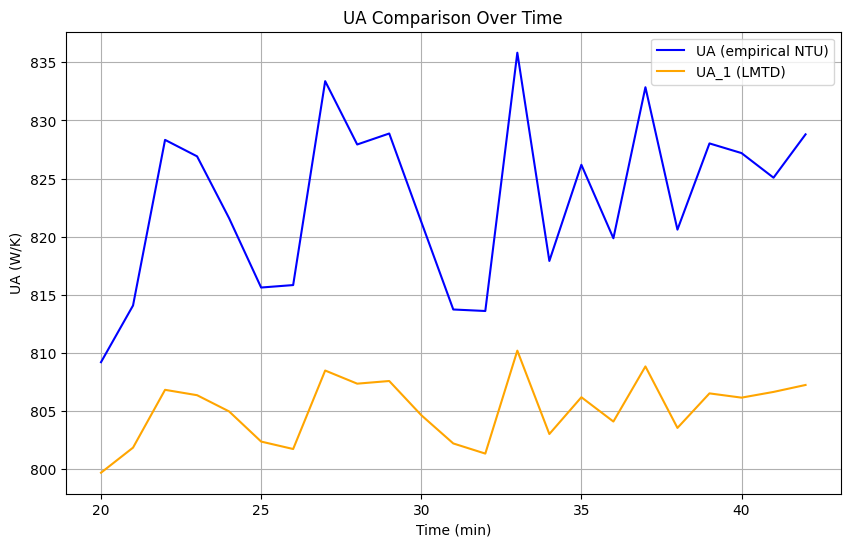

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(time_req, UA_req, label='UA (empirical NTU)', color='blue')
plt.plot(time_req, UA_1_req, label='UA_1 (LMTD)', color='orange')
plt.xlabel('Time (min)')
plt.ylabel('UA (W/K)')
plt.title('UA Comparison Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
U_inner=UA/coolant_SA
U_outer=UA/air_SA

In [17]:
U_inner_req = U_inner[time >=20]
U_outer_req = U_outer[time >=20]

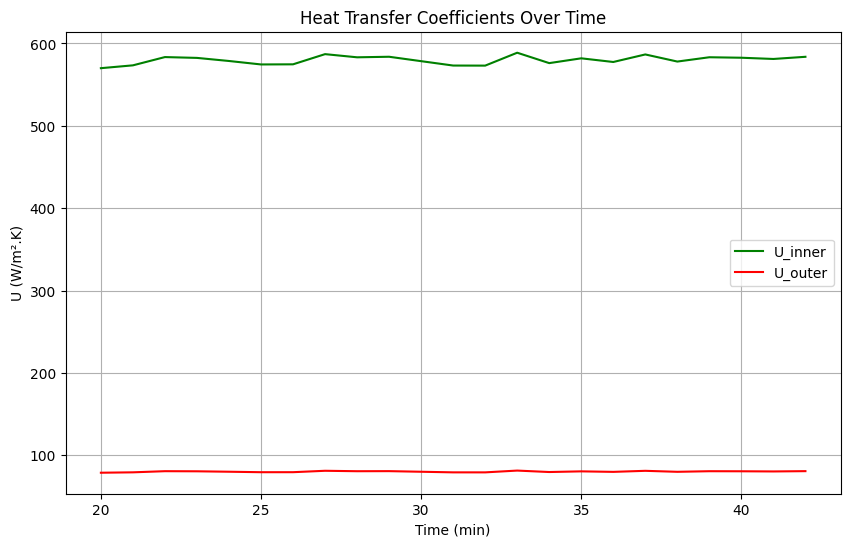

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(time_req, U_inner_req, label='U_inner', color='green')
plt.plot(time_req, U_outer_req, label='U_outer', color='red')
plt.xlabel('Time (min)')
plt.ylabel('U (W/m².K)')
plt.title('Heat Transfer Coefficients Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
UA_1_inner=UA_1/coolant_SA
UA_1_outer=UA_1/air_SA
UA_1_inner_req = UA_1_inner[time >=20]
UA_1_outer_req = UA_1_outer[time >=20]

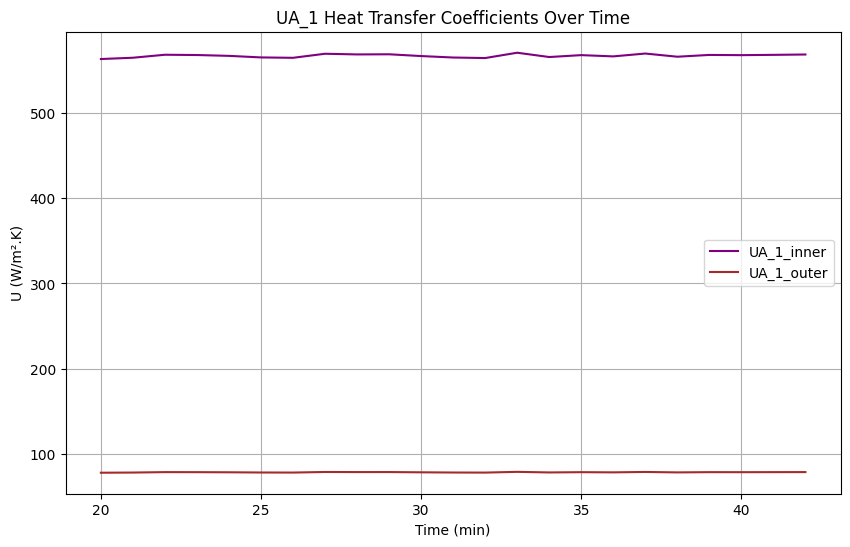

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(time_req, UA_1_inner_req, label='UA_1_inner', color='purple')
plt.plot(time_req, UA_1_outer_req, label='UA_1_outer', color='brown')
plt.xlabel('Time (min)')
plt.ylabel('U (W/m².K)')
plt.title('UA_1 Heat Transfer Coefficients Over Time')
plt.legend()
plt.grid(True)
plt.show()
